In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
df = pd.read_csv("insurance.csv")

In [3]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [5]:
print("Numerical Features:")
print(df.select_dtypes(include=['int64','float64']).columns.tolist())

print("\nCategorical Features:")
print(df.select_dtypes(include=['object']).columns.tolist())

print("\nTarget Variable:")
print("charges")

Numerical Features:
['age', 'bmi', 'children', 'charges']

Categorical Features:
['sex', 'smoker', 'region']

Target Variable:
charges


In [6]:
df.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [7]:
le = LabelEncoder()

df["sex"] = le.fit_transform(df["sex"])
df["smoker"] = le.fit_transform(df["smoker"])
df["region"] = le.fit_transform(df["region"])

df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,0,27.900,0,1,3,16884.92400
1,18,1,33.770,1,0,2,1725.55230
2,28,1,33.000,3,0,2,4449.46200
3,33,1,22.705,0,0,1,21984.47061
4,32,1,28.880,0,0,1,3866.85520


In [8]:
X = df.drop("charges", axis=1)
y = df["charges"]

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [10]:
model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [12]:
y_pred = model.predict(X_test)

print(y_pred[:10])

[ 8924.40724442  7116.29501758 36909.01352144  9507.87469118
 27013.3500079  10790.77956153   226.29844571 16942.71599941
  1056.63079407 11267.91997309]


In [13]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error :", mae)
print("Mean Squared Error :", mse)
print("R2 Score :", r2)

Mean Absolute Error : 4186.508898366433
Mean Squared Error : 33635210.431178406
R2 Score : 0.7833463107364539


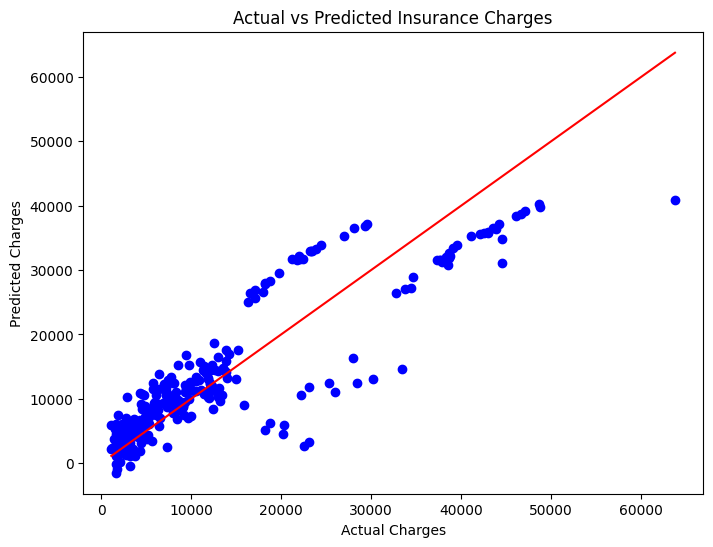

In [14]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred, color='blue')

plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Actual vs Predicted Insurance Charges")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red'
)

plt.show()

1. The model achieved a good R² score, indicating that it explains a significant portion of the variance in insurance charges.

2. The scatter plot shows that most predicted values are close to the actual values, although some higher insurance charges are not predicted accurately.

3. Smoking status, age, and BMI appear to have a strong influence on insurance costs.

CONCLUSION:


This project developed a Multiple Linear Regression model to predict medical insurance charges using customer information such as age, sex, BMI, number of children, smoking status, and region. After preprocessing the dataset by encoding categorical variables and splitting it into training and testing sets, the model achieved a good R² score, indicating satisfactory predictive performance. Among all the features, smoking status, age, and BMI had the greatest impact on insurance charges. However, Linear Regression assumes a linear relationship between features and the target variable, which may not capture complex interactions in real-world medical insurance data. More advanced models such as Random Forest or Gradient Boosting may provide better prediction accuracy.